# yy08 — UMAP Label Transfer Demo

Demonstrates `UMAPLabelTransfer` for four combinations:

| Cell | Cell type | UMAP mode |
|------|-----------|------------|
| 1 | EXC | unsupervised |
| 2 | EXC | supervised   |
| 3 | INH | unsupervised |
| 4 | INH | supervised   |

Each cell calls the full pipeline: load → harmonise → (optionally save h5ad) → scale → UMAP → KNN transfer → plot.

In [1]:
import sys
import os

# Ensure the code/ directory is on the path so utils and the class are importable
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from umap_label_transfer import UMAPLabelTransfer

DATA_ROOT = '/scratch/combined_datasets'

## Cell 1 — EXC · unsupervised UMAP

Patchseq features: (389, 53)
Unique patchseq cells: 384, unique labels: 17
Patchseq after label join: (384, 56)
Minnie features: (49714, 58)
Shared features:  48
Only in patchseq: 4  → ['axon_exit_theta', 'axon_exit_distance', 'heirachy_category', 'level']
Only in minnie:   7  → ['basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_4', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_5', 'basal_dendrite_depth_pc_0', 'soma_surface_area', 'basal_dendrite_depth_pc_2']
Patchseq: 384 → 384 rows (dropped 0)
Minnie:   49714 → 49714 rows (dropped 0)


/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


Saved patchseq h5ad → /results/h5ad_outputs/exc_patchseq_harmonized.h5ad  (384, 48)
Saved minnie h5ad  → /results/h5ad_outputs/exc_minnie_harmonized.h5ad  (49714, 48)
Scaled patchseq (standard): (384, 48)
Scaled minnie   (standard): (49714, 48)


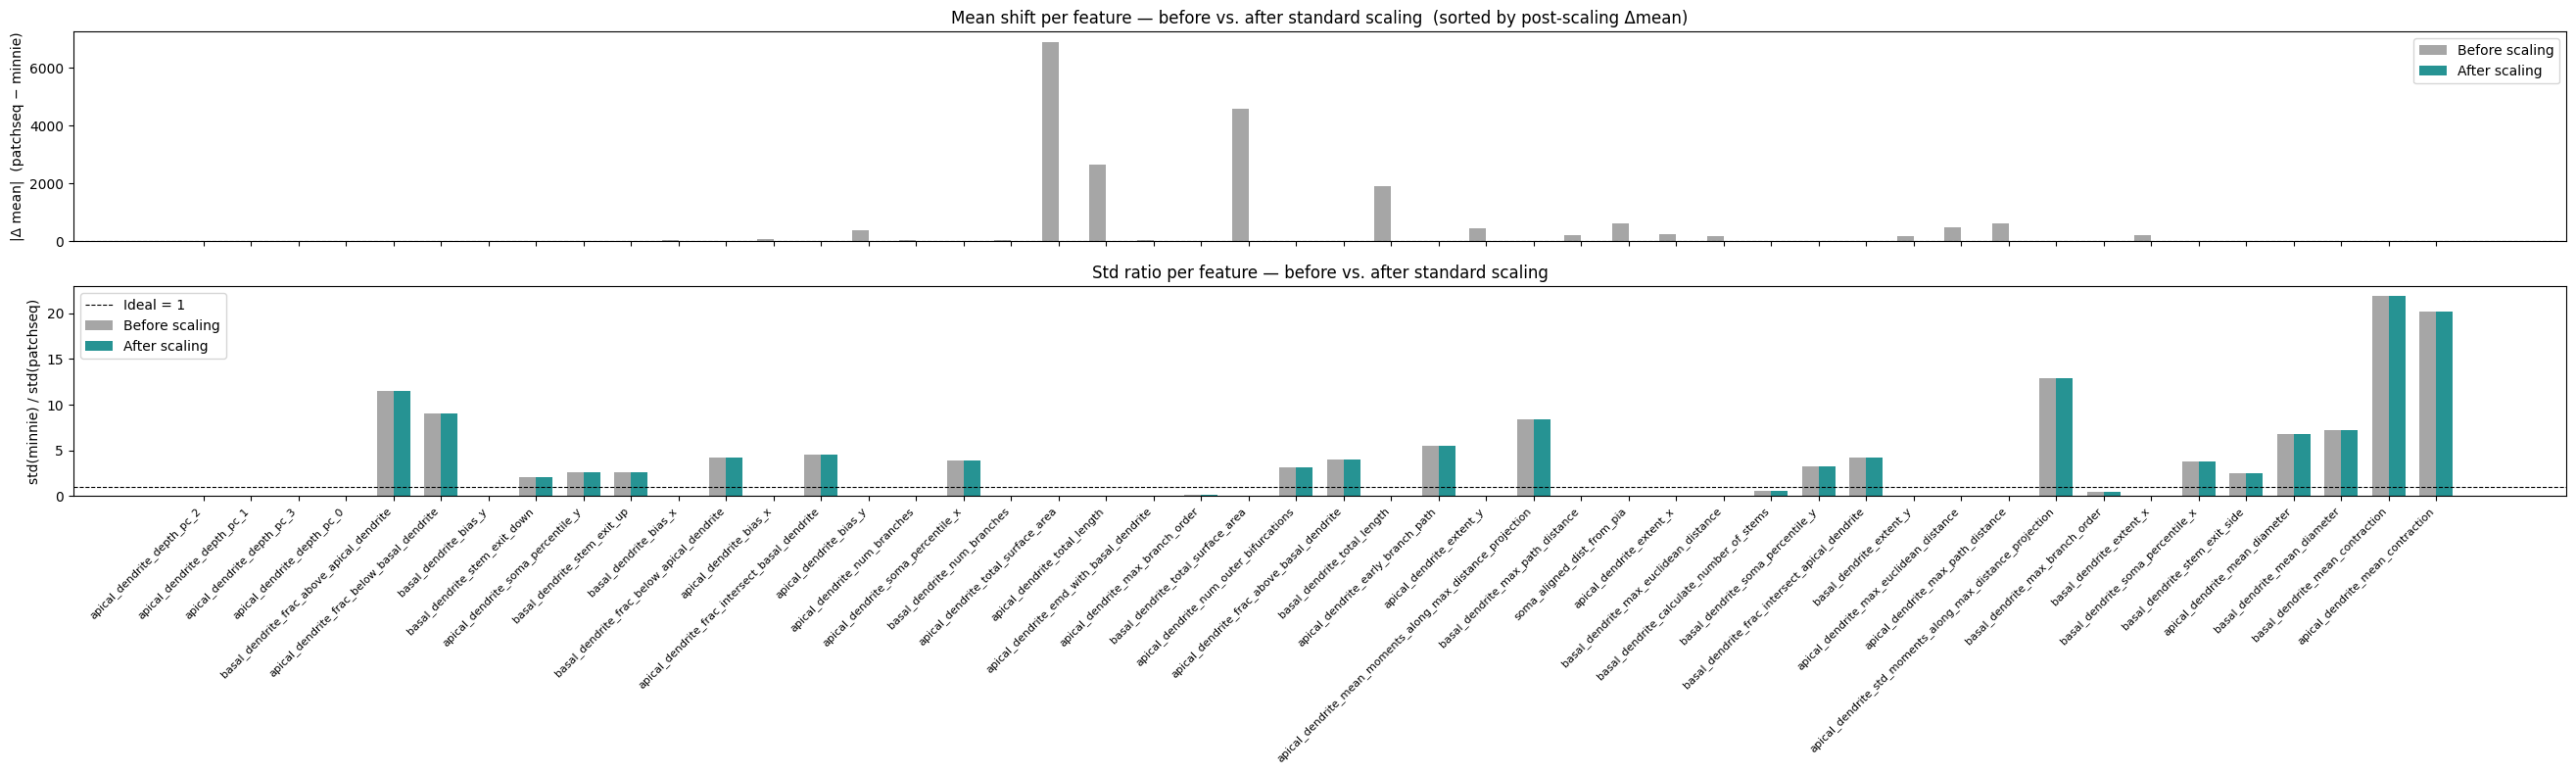

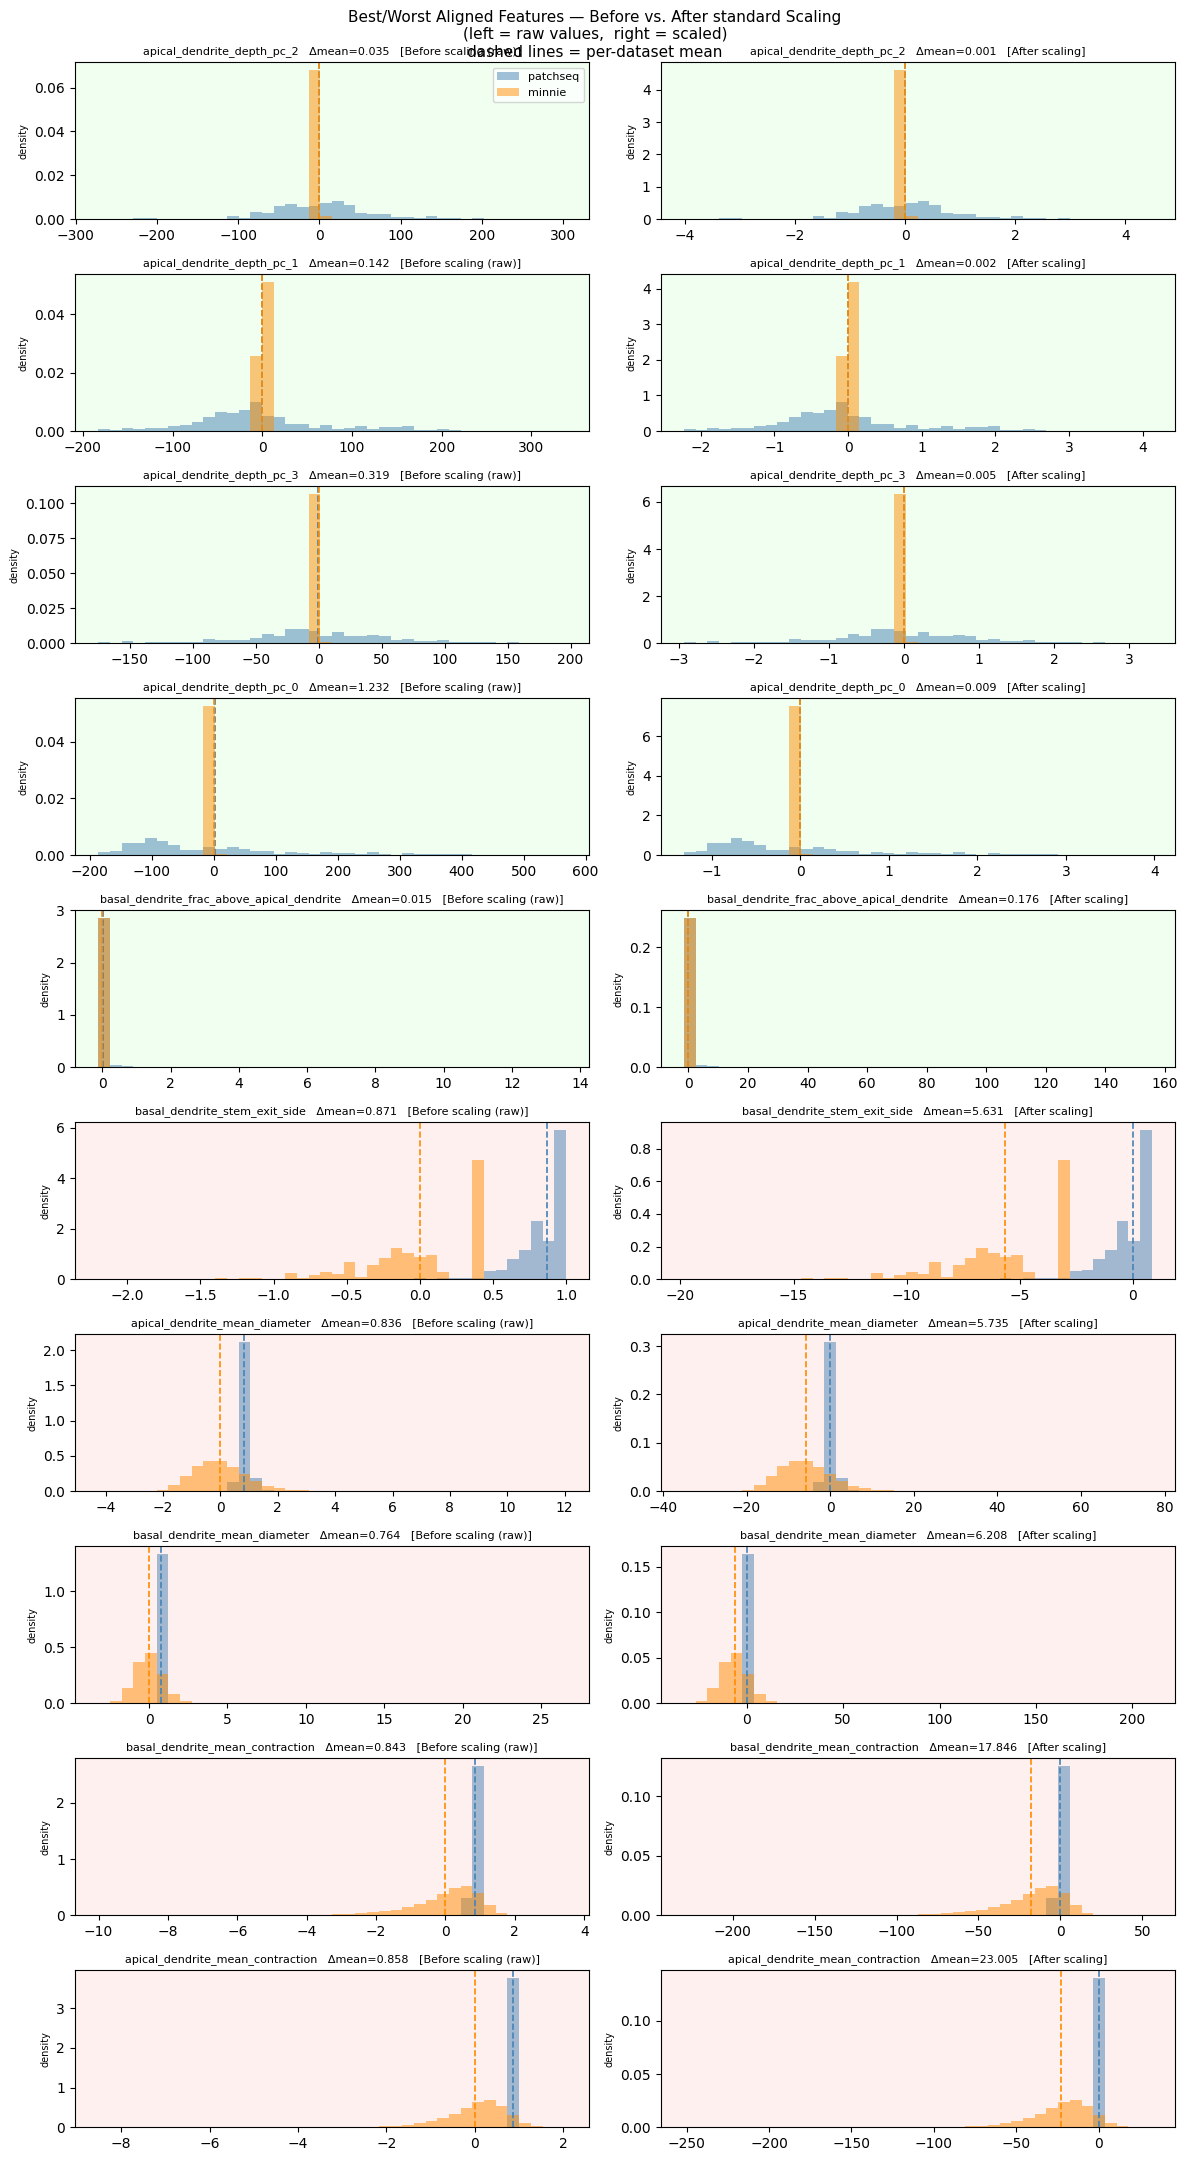

/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Patchseq embedding (unsupervised): (384, 2)
Minnie embedding   (unsupervised): (49714, 2)
Minnie predicted label counts:
  L6 IT-2                                            16590
  L4 IT                                              16196
  L6b                                                5613
  L2/3 IT                                            5498
  L6 IT-1                                            1814
  L5/L6 IT Car3                                      977
  L6 CT-2                                            877
  L5 NP                                              842
  L6 CT-1                                            723
  L5 IT-1                                            244
  L4/L5 IT                                           111
  L5 ET-2                                            64
  L6 IT-3                                            63
  L5 IT-2                                            62
  L5 IT-3 Pld5                                       40


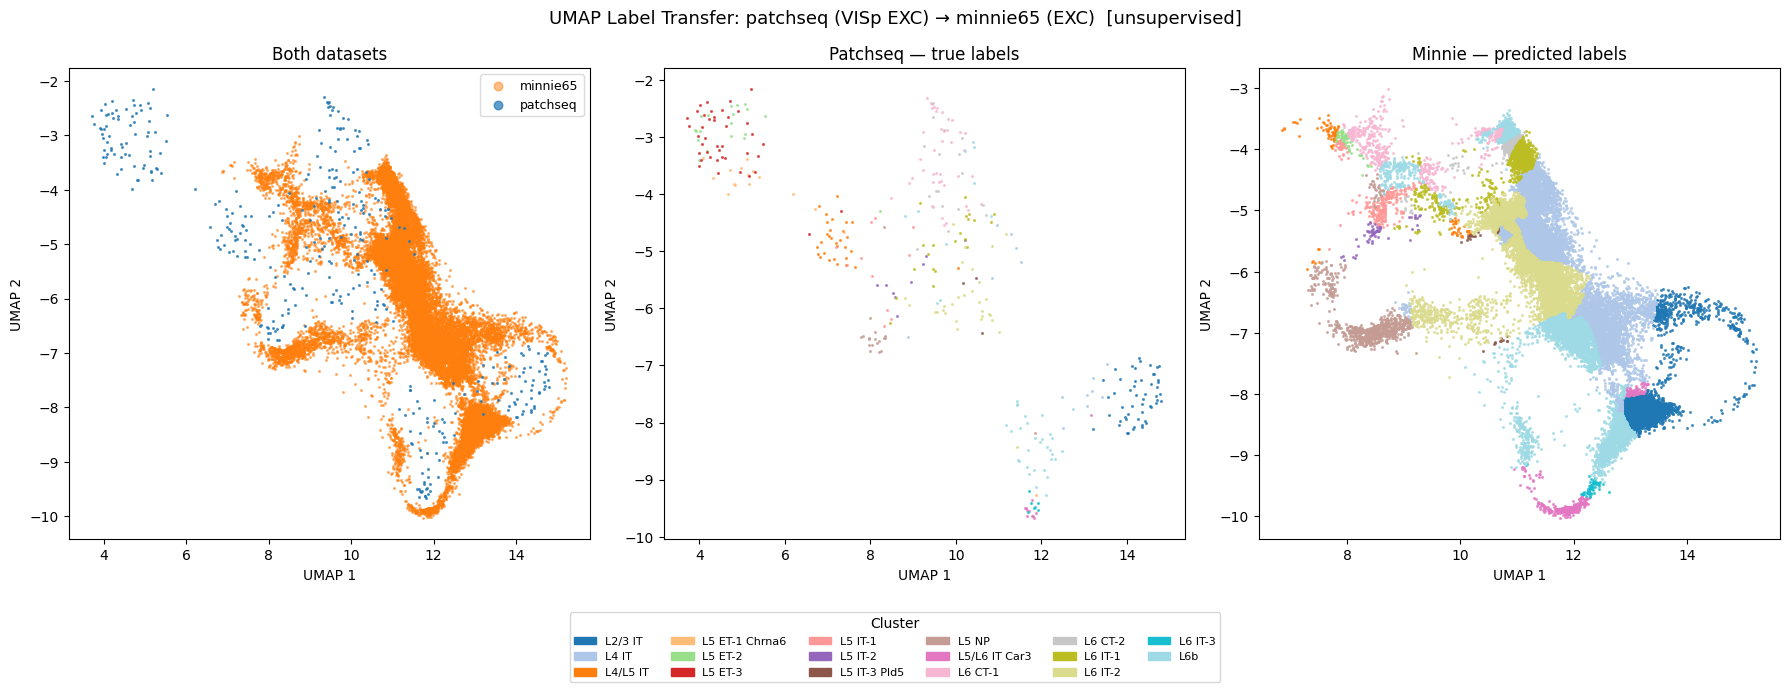

In [2]:
lt_exc_unsup = UMAPLabelTransfer(DATA_ROOT, cell_type='exc')
lt_exc_unsup.load_data()
lt_exc_unsup.harmonize_features()
lt_exc_unsup.save_harmonized_h5ad('/results/h5ad_outputs')  # optional
lt_exc_unsup.scale(method='standard')
lt_exc_unsup.plot_alignment_diagnostics(top_n=5)
lt_exc_unsup.fit_umap(mode='unsupervised')
lt_exc_unsup.transfer_labels(k=3)
lt_exc_unsup.plot_umap()

## Cell 2 — EXC · supervised UMAP

Patchseq features: (389, 53)
Unique patchseq cells: 384, unique labels: 17
Patchseq after label join: (384, 56)
Minnie features: (49714, 58)
Shared features:  48
Only in patchseq: 4  → ['axon_exit_theta', 'axon_exit_distance', 'heirachy_category', 'level']
Only in minnie:   7  → ['basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_4', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_5', 'basal_dendrite_depth_pc_0', 'soma_surface_area', 'basal_dendrite_depth_pc_2']
Patchseq: 384 → 384 rows (dropped 0)
Minnie:   49714 → 49714 rows (dropped 0)
Scaled patchseq (standard): (384, 48)
Scaled minnie   (standard): (49714, 48)


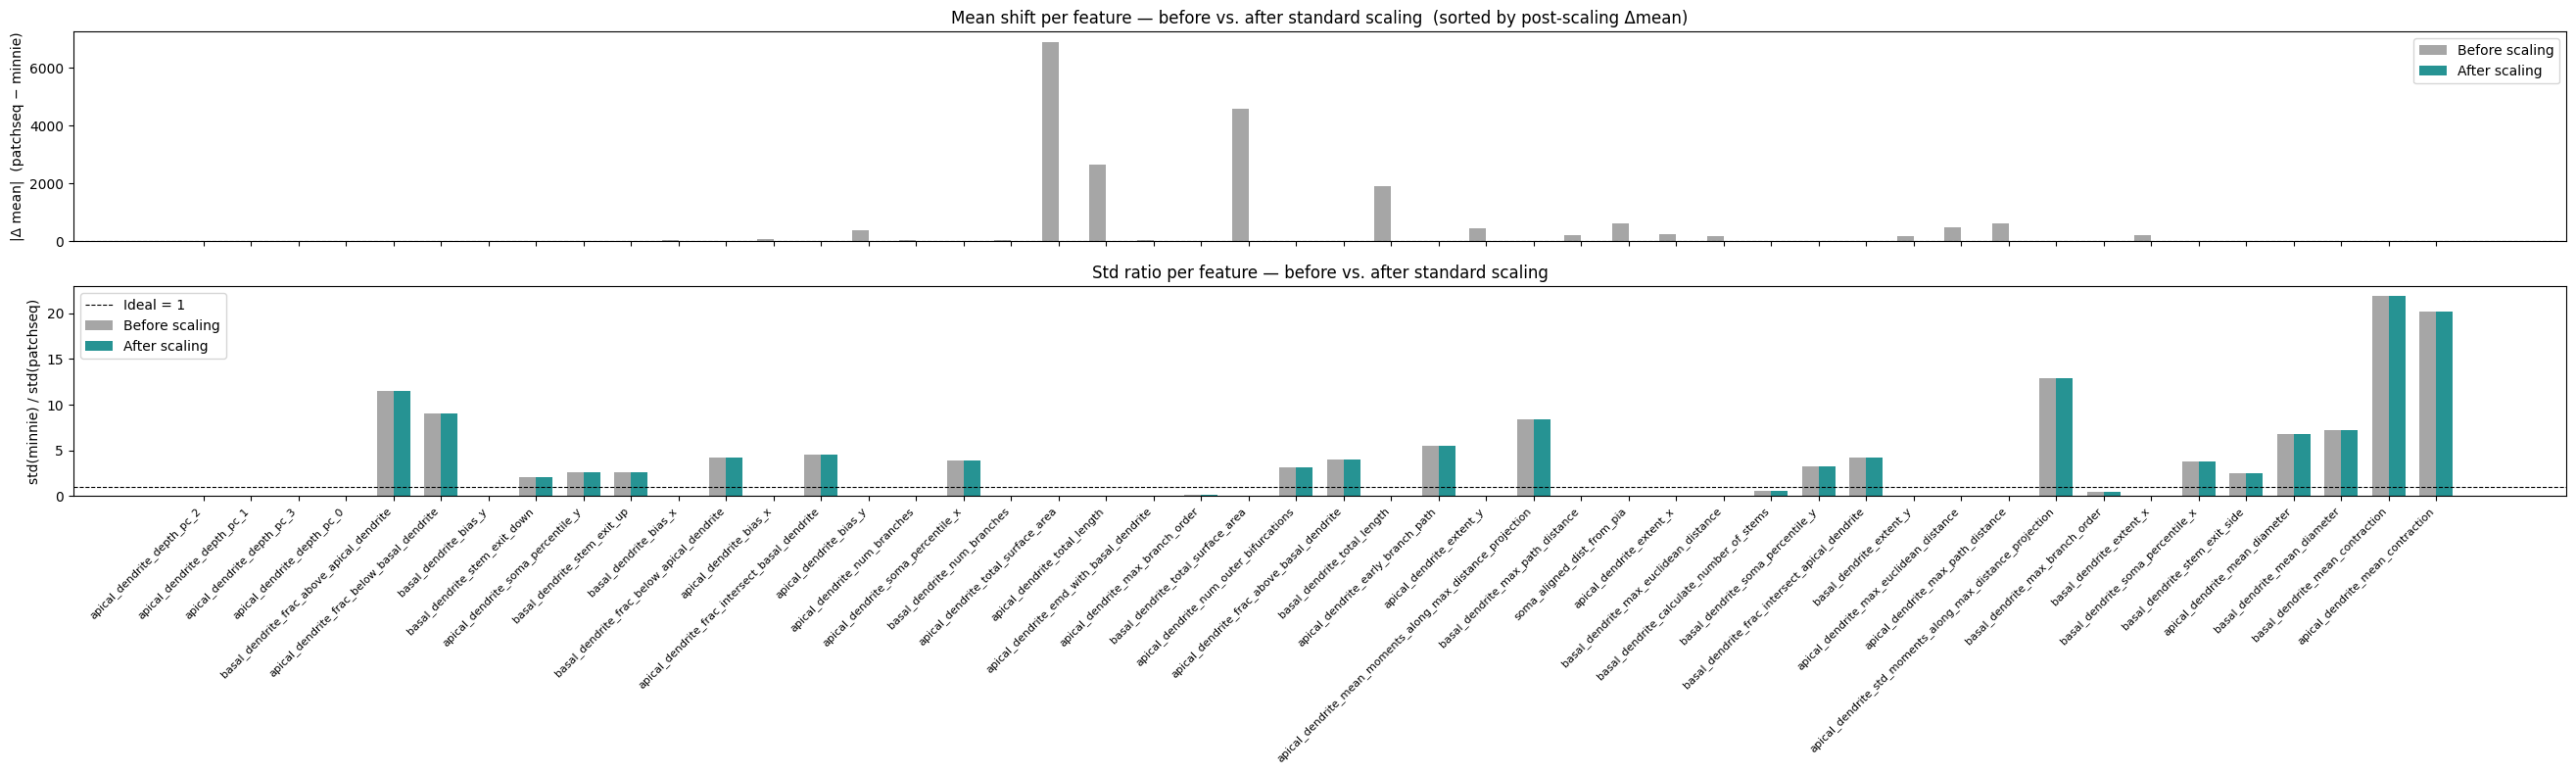

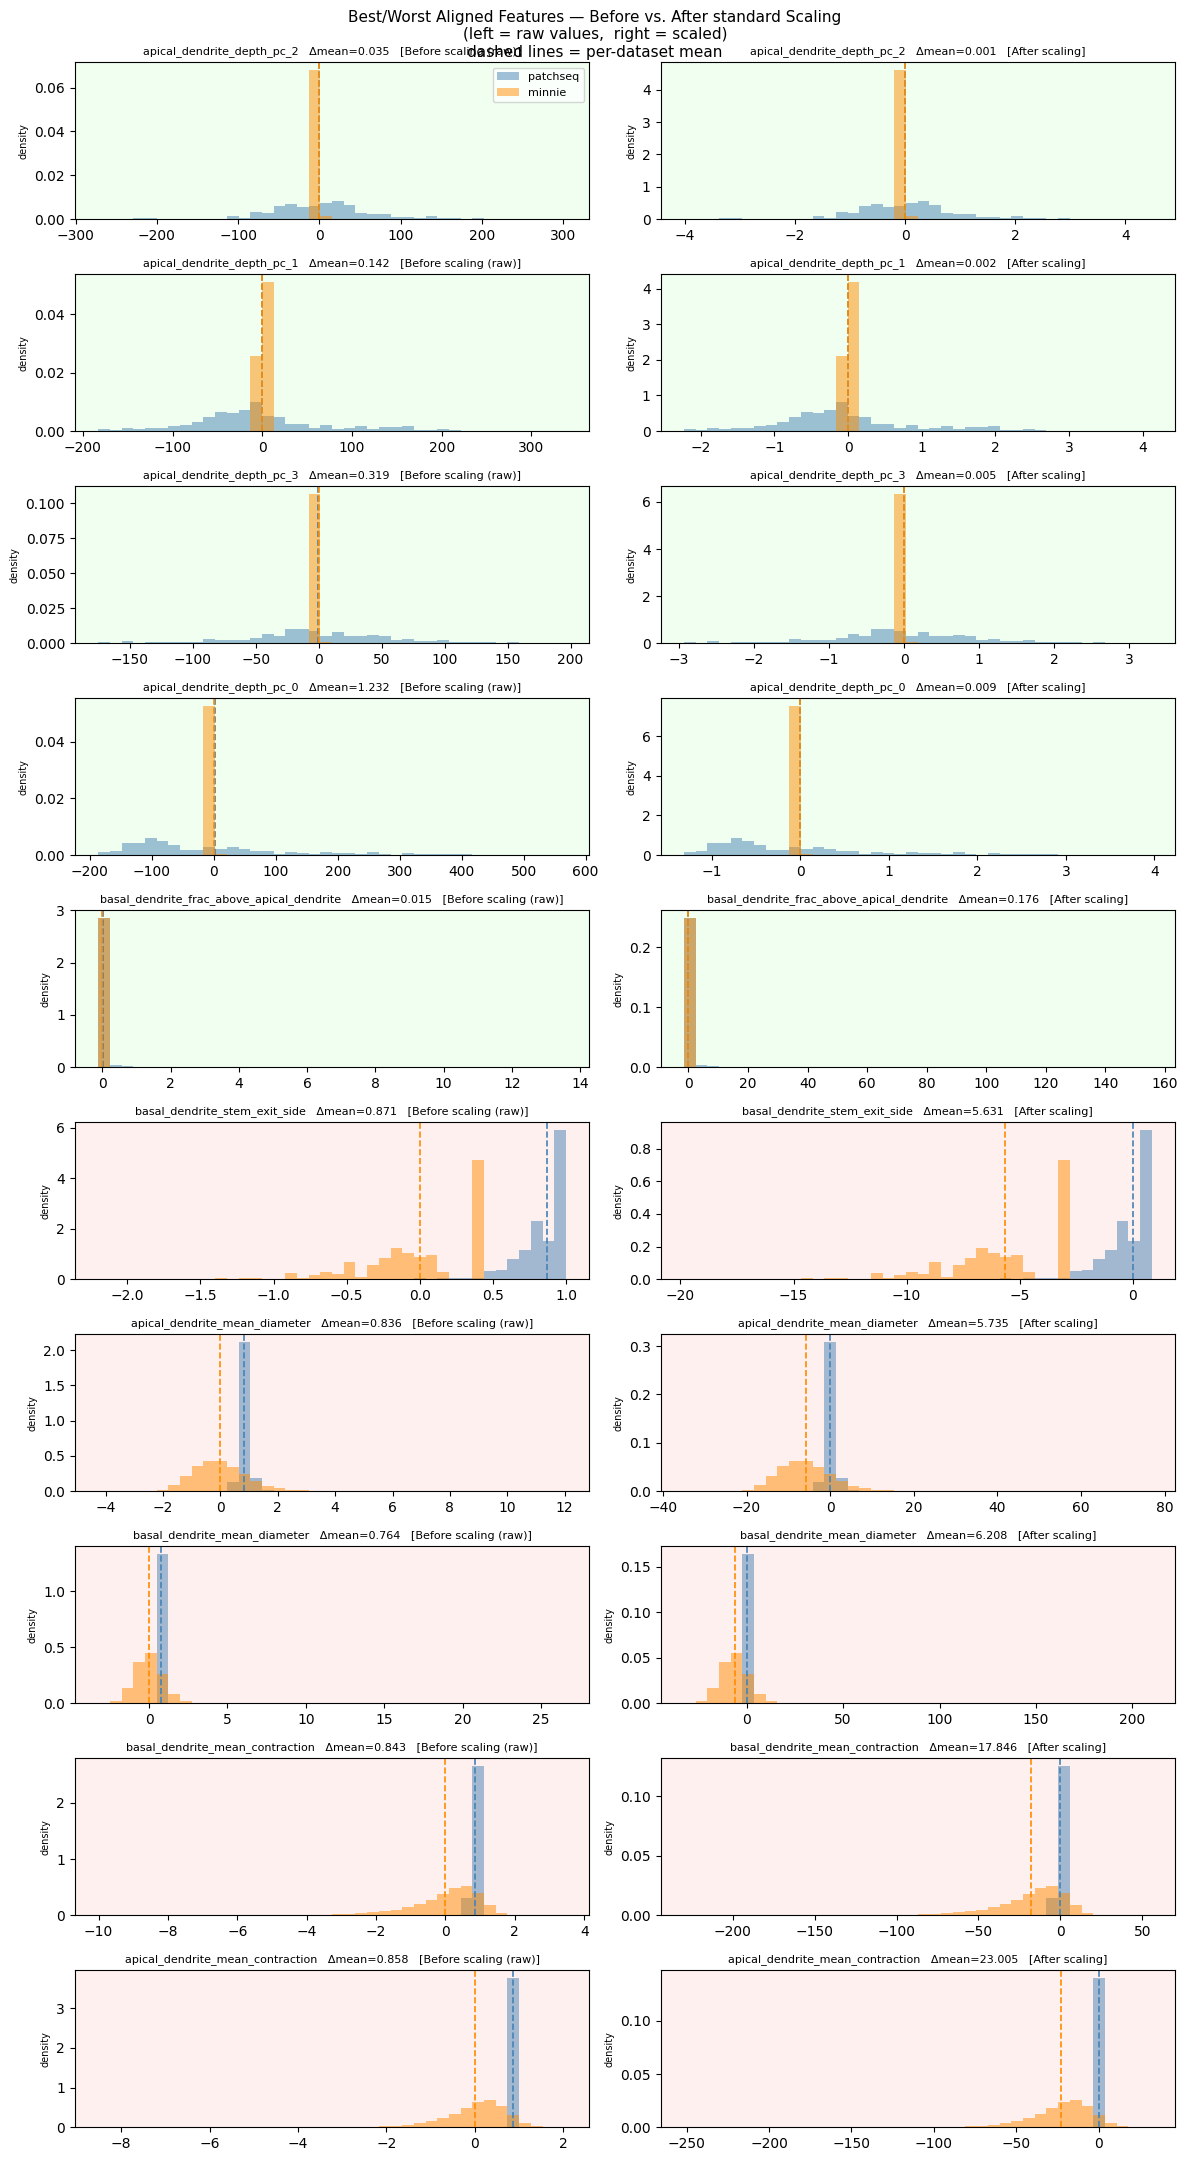

Patchseq embedding (supervised): (384, 2)
Minnie embedding   (supervised): (49714, 2)
Minnie predicted label counts:
  L4 IT                                              13551
  L5 IT-2                                            9146
  L5 IT-1                                            8463
  L6 IT-1                                            4860
  L5 IT-3 Pld5                                       3292
  L5/L6 IT Car3                                      2995
  L4/L5 IT                                           2360
  L5 NP                                              956
  L6b                                                903
  L6 CT-1                                            772
  L2/3 IT                                            687
  L6 IT-2                                            675
  L6 CT-2                                            363
  L6 IT-3                                            315
  L5 ET-3                                            211
  L5 ET-1 Chrna6    

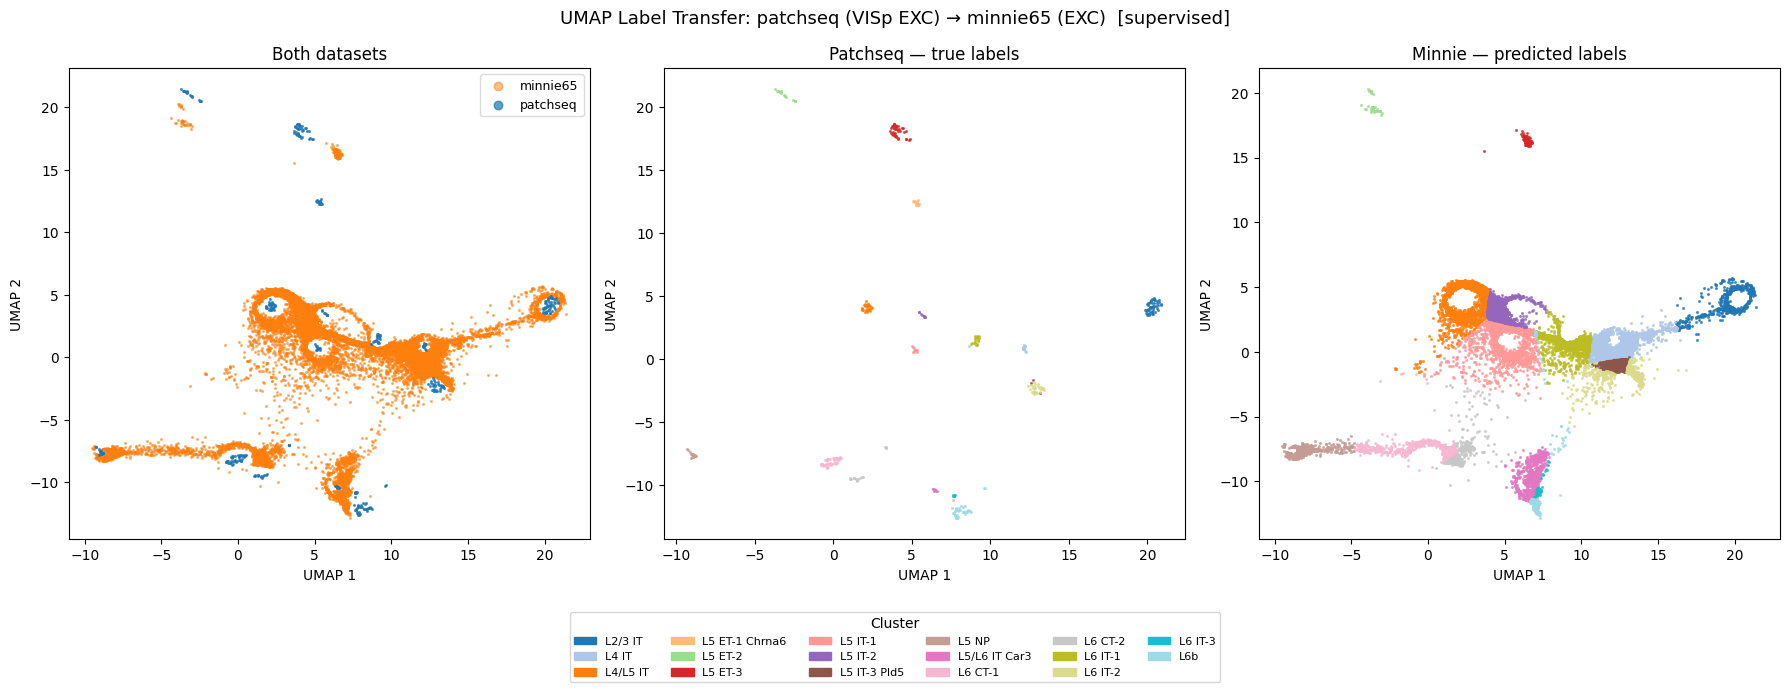

In [3]:
lt_exc_sup = UMAPLabelTransfer(DATA_ROOT, cell_type='exc')
lt_exc_sup.load_data()
lt_exc_sup.harmonize_features()
# lt_exc_sup.save_harmonized_h5ad('/scratch/h5ad_outputs')  # optional
lt_exc_sup.scale(method='standard')
lt_exc_sup.plot_alignment_diagnostics(top_n=5)
lt_exc_sup.fit_umap(mode='supervised')
lt_exc_sup.transfer_labels(k=3)
lt_exc_sup.plot_umap()

## Cell 3 — INH · unsupervised UMAP

Patchseq features: (520, 49)
Unique patchseq cells: 495, unique labels: 28
Patchseq after label join: (495, 52)
Minnie features: (163, 54)
Shared features:  46
Only in patchseq: 2  → ['heirachy_category', 'level']
Only in minnie:   5  → ['basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_4', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_2']
Patchseq: 495 → 495 rows (dropped 0)
Minnie:   163 → 163 rows (dropped 0)
Saved patchseq h5ad → /results/h5ad_outputs/inh_patchseq_harmonized.h5ad  (495, 46)
Saved minnie h5ad  → /results/h5ad_outputs/inh_minnie_harmonized.h5ad  (163, 46)
Scaled patchseq (standard): (495, 46)
Scaled minnie   (standard): (163, 46)


/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


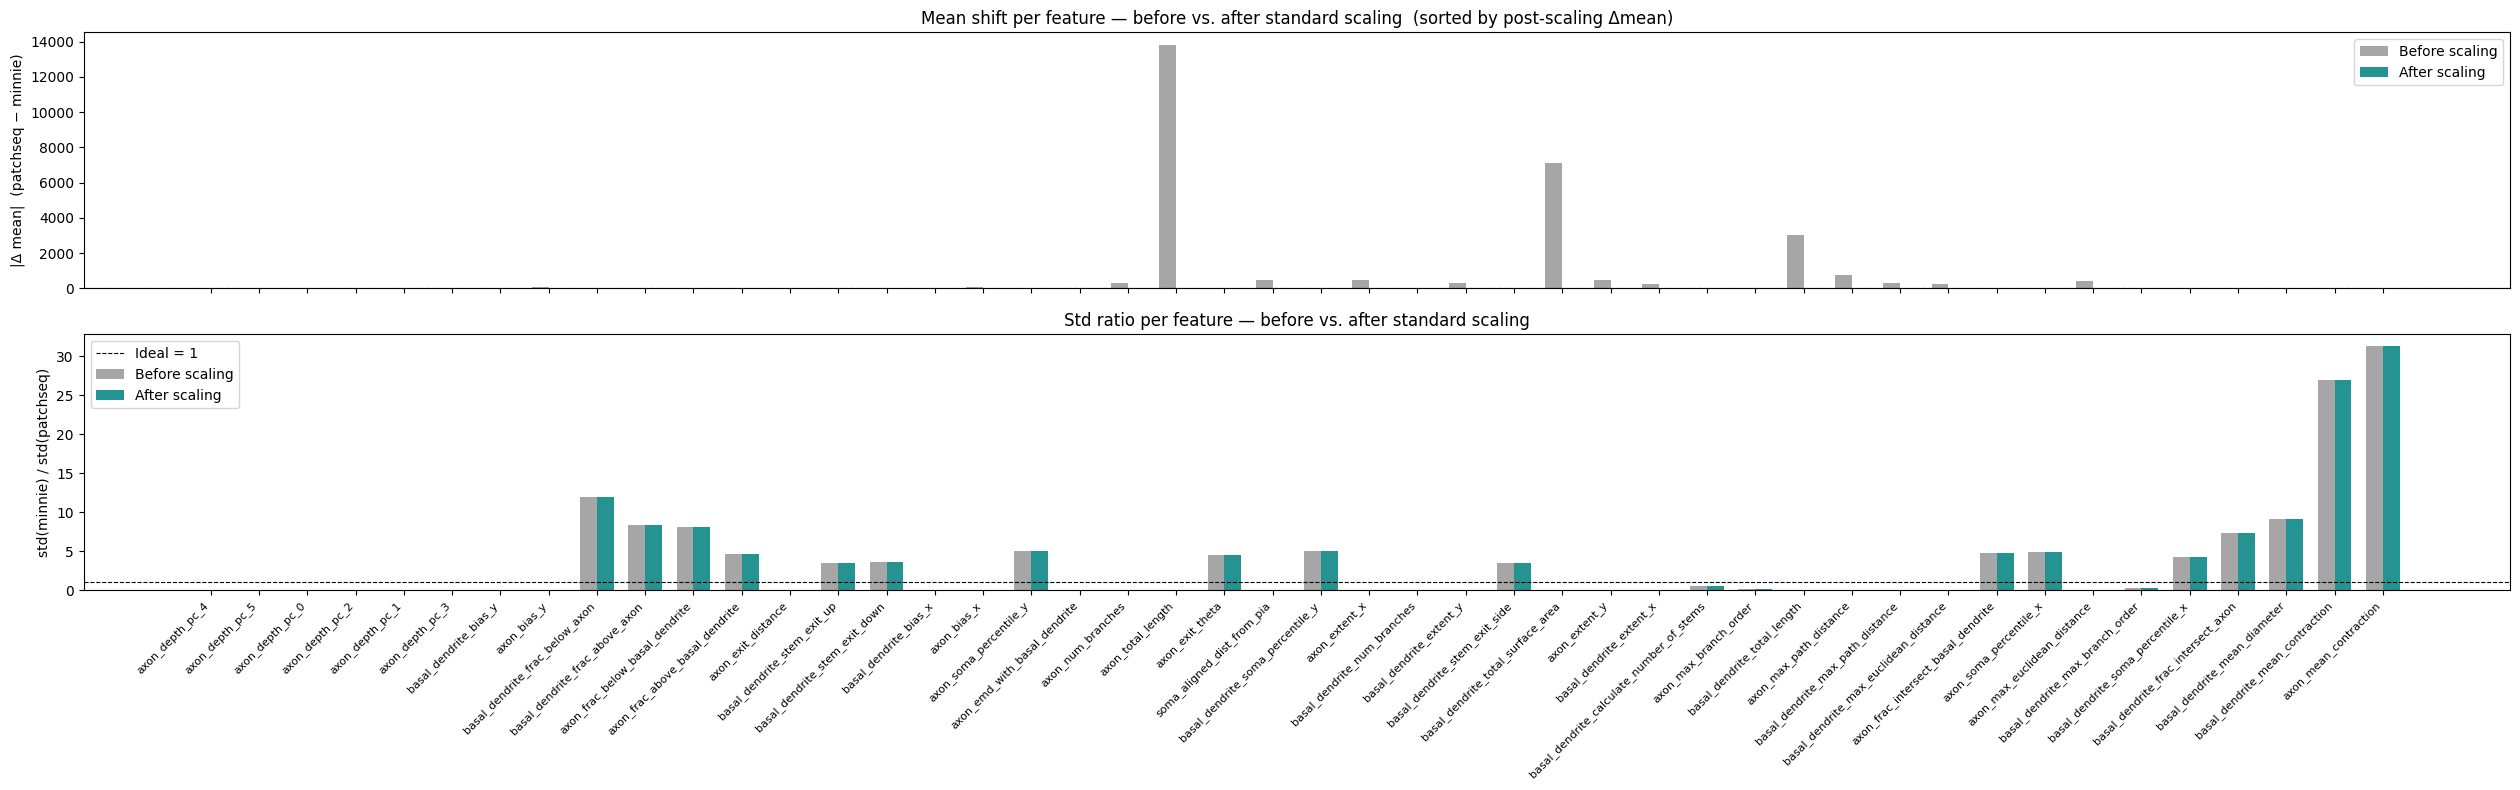

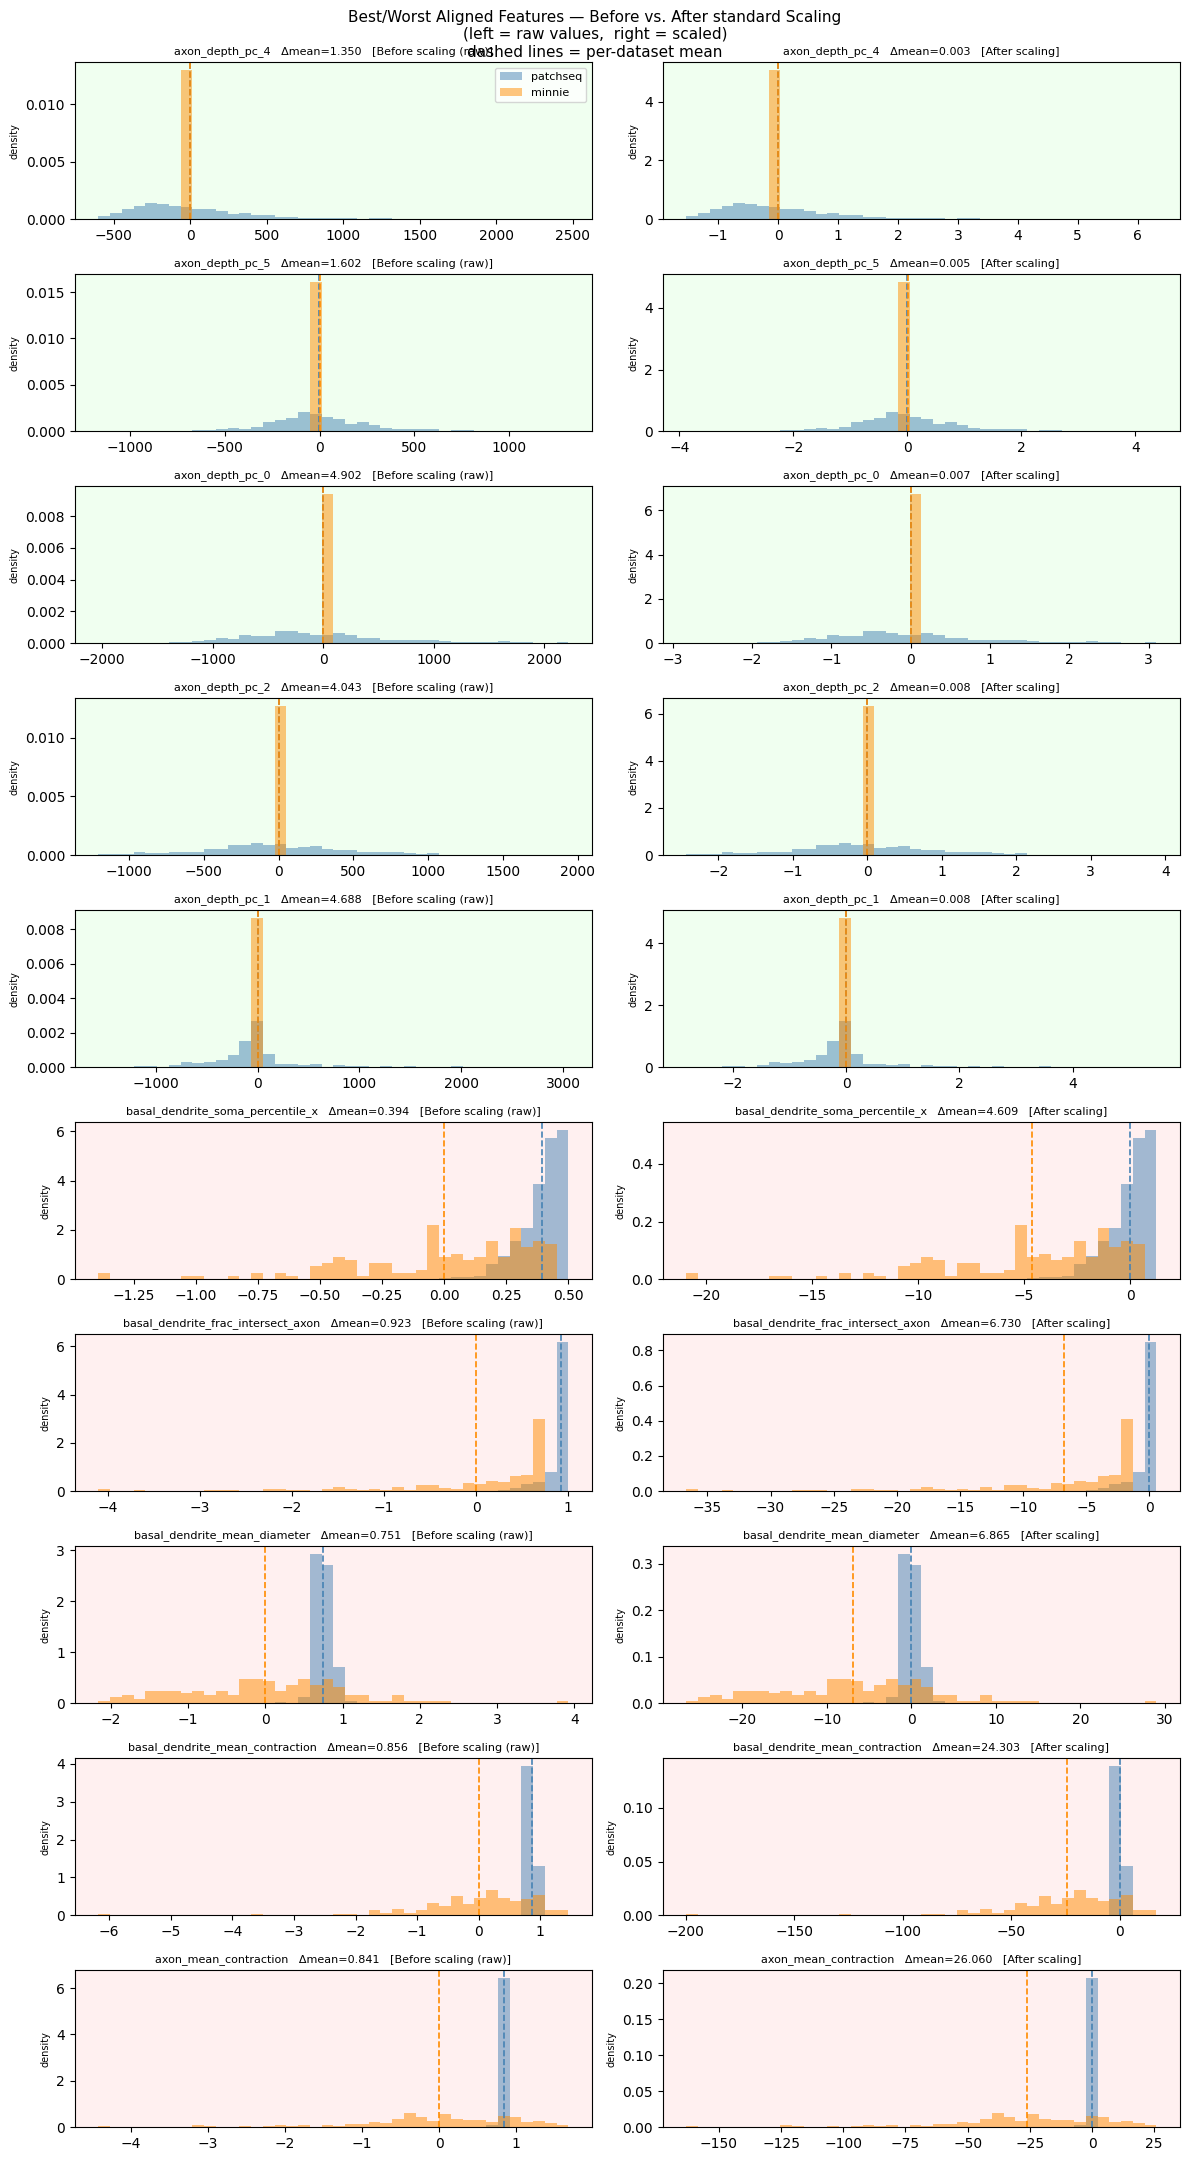

/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Patchseq embedding (unsupervised): (495, 2)
Minnie embedding   (unsupervised): (163, 2)
Minnie predicted label counts:
  Vip-MET-5                                          35
  Sncg-MET-1                                         28
  Vip-MET-1                                          28
  Lamp5-MET-1                                        11
  Pvalb-MET-4                                        10
  Sst-MET-9                                          9
  Vip-MET-4                                          8
  Sst-MET-7                                          6
  Sst-MET-12                                         5
  Pvalb-MET-1                                        4
  Sst-MET-10                                         4
  Sst-MET-3                                          4
  Sst-MET-6                                          3
  Vip-MET-2                                          2
  Pvalb-MET-5                                        1
  Sst-MET-1                                        

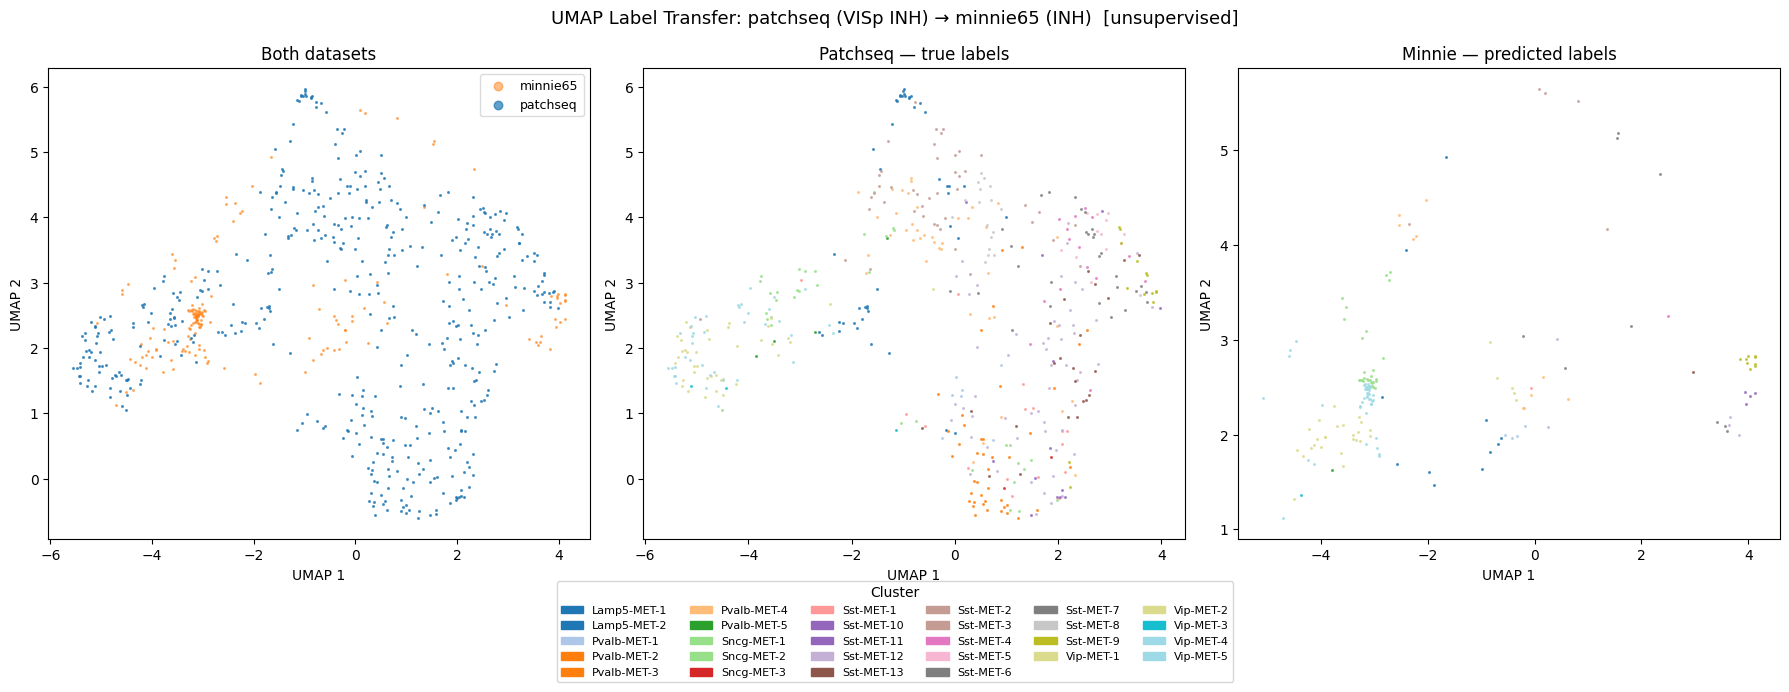

In [4]:
lt_inh_unsup = UMAPLabelTransfer(DATA_ROOT, cell_type='inh')
lt_inh_unsup.load_data()
lt_inh_unsup.harmonize_features()
lt_inh_unsup.save_harmonized_h5ad('/results/h5ad_outputs')  # optional
lt_inh_unsup.scale(method='standard')
lt_inh_unsup.plot_alignment_diagnostics(top_n=5)
lt_inh_unsup.fit_umap(mode='unsupervised')
lt_inh_unsup.transfer_labels(k=3)
lt_inh_unsup.plot_umap()

## Cell 4 — INH · supervised UMAP

Patchseq features: (520, 49)
Unique patchseq cells: 495, unique labels: 28
Patchseq after label join: (495, 52)
Minnie features: (163, 54)
Shared features:  46
Only in patchseq: 2  → ['heirachy_category', 'level']
Only in minnie:   5  → ['basal_dendrite_depth_pc_1', 'basal_dendrite_depth_pc_4', 'basal_dendrite_depth_pc_3', 'basal_dendrite_depth_pc_0', 'basal_dendrite_depth_pc_2']
Patchseq: 495 → 495 rows (dropped 0)
Minnie:   163 → 163 rows (dropped 0)
Scaled patchseq (standard): (495, 46)
Scaled minnie   (standard): (163, 46)


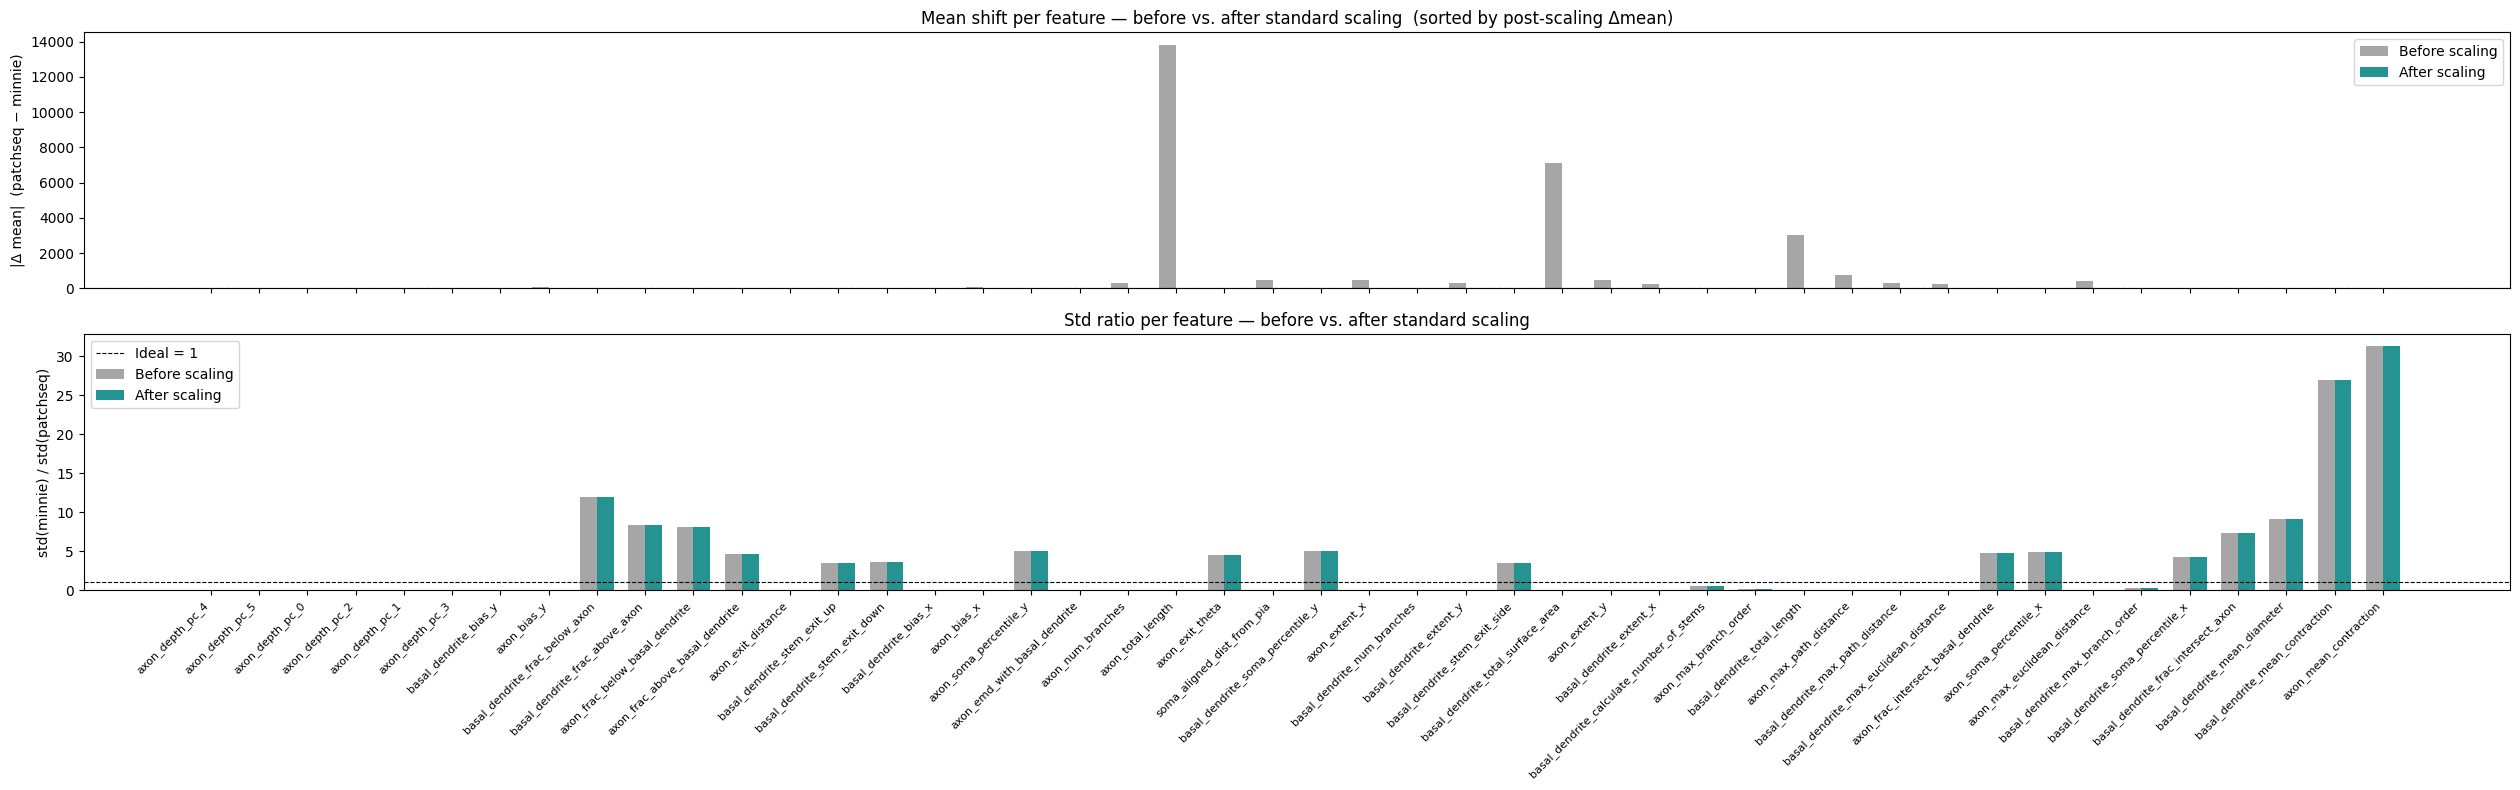

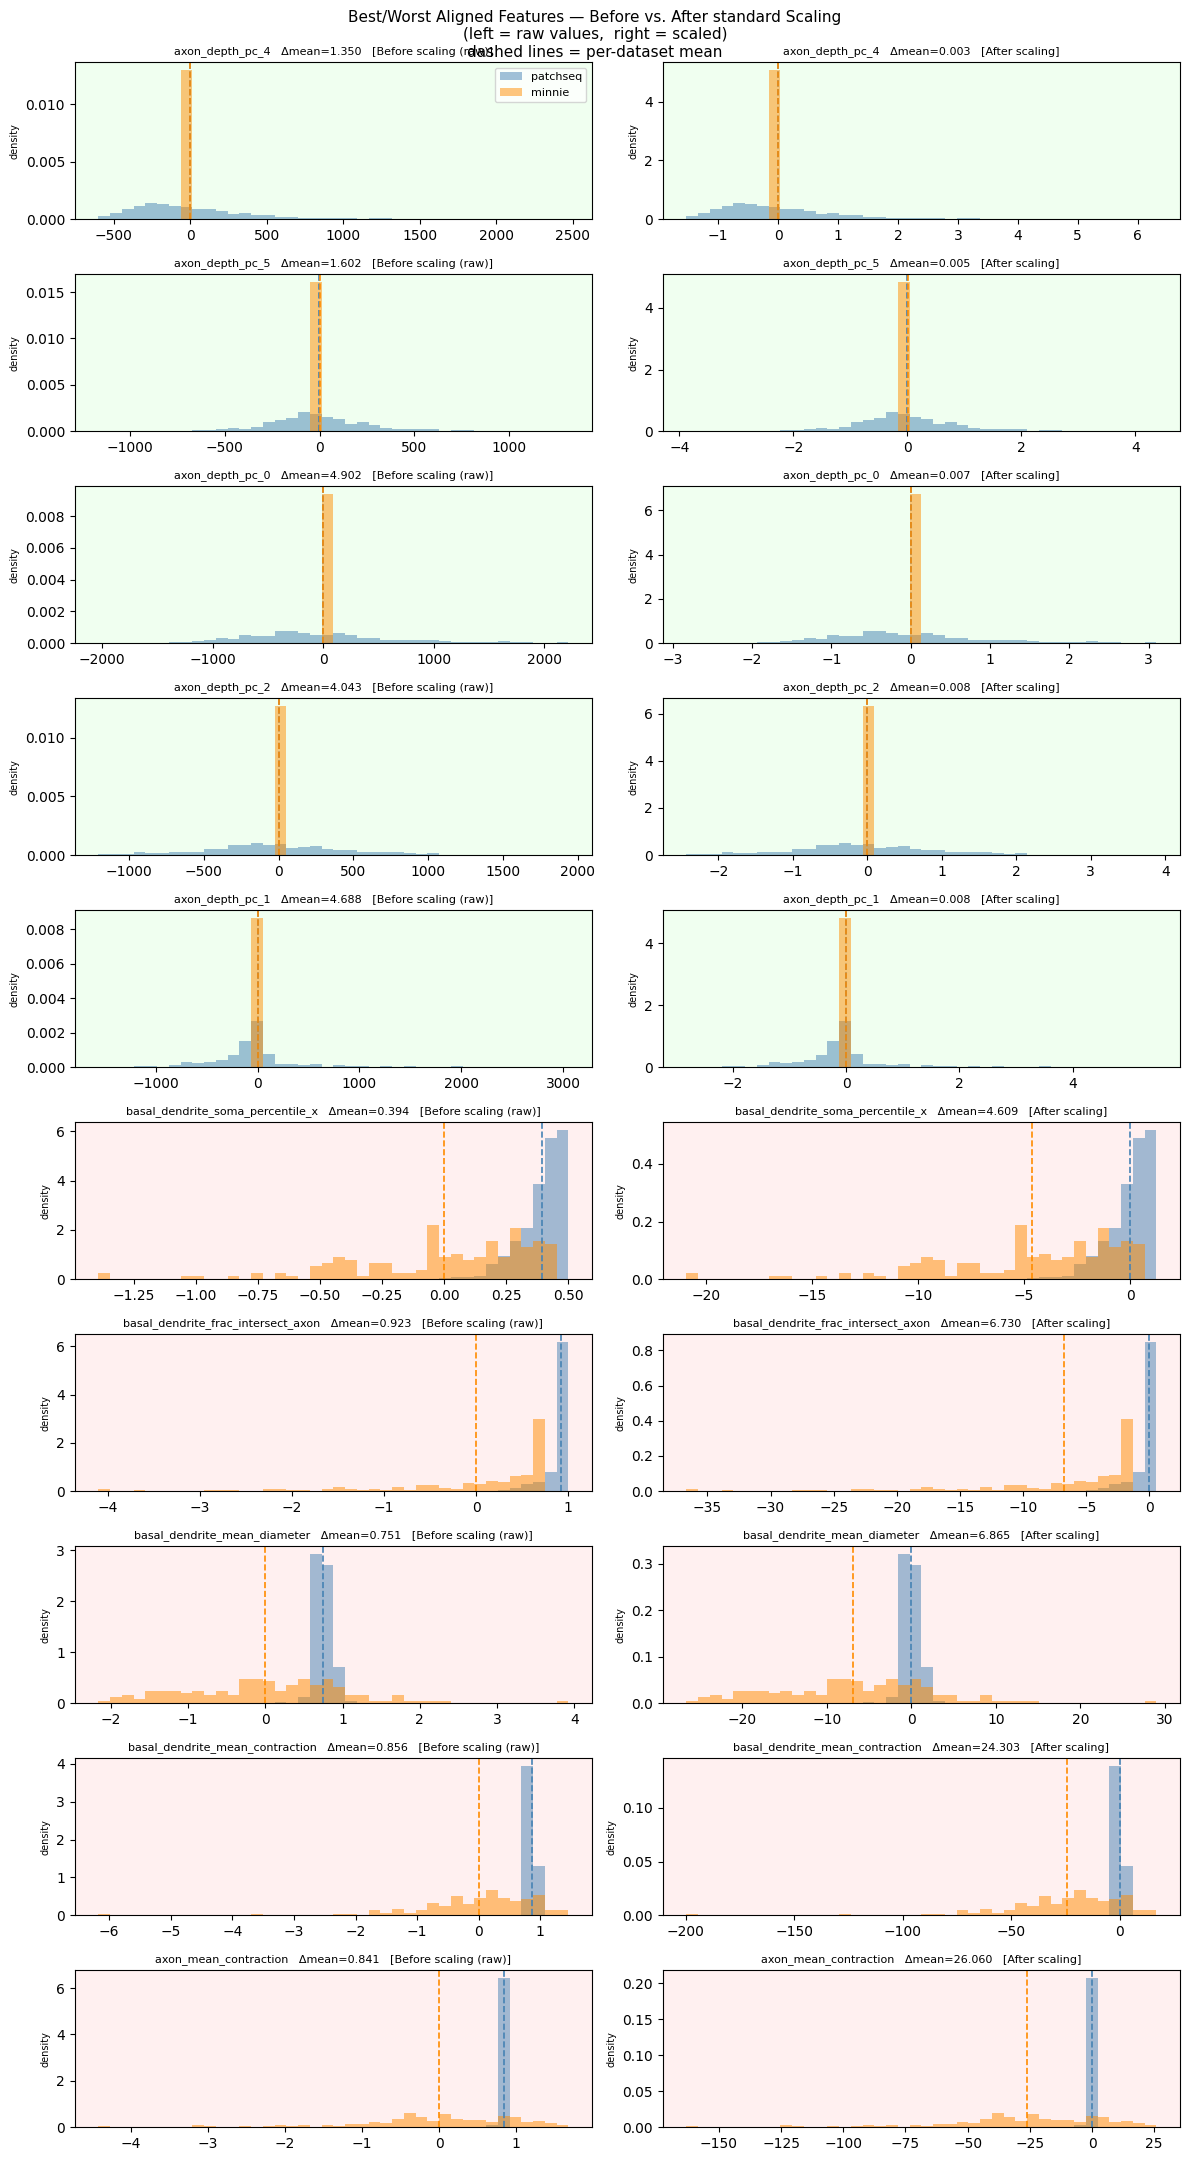

Patchseq embedding (supervised): (495, 2)
Minnie embedding   (supervised): (163, 2)
Minnie predicted label counts:
  Vip-MET-5                                          54
  Vip-MET-2                                          27
  Sst-MET-9                                          12
  Vip-MET-1                                          12
  Pvalb-MET-4                                        11
  Pvalb-MET-3                                        8
  Sst-MET-7                                          8
  Pvalb-MET-1                                        7
  Sst-MET-1                                          6
  Sst-MET-12                                         4
  Sst-MET-2                                          3
  Lamp5-MET-1                                        2
  Sst-MET-10                                         2
  Sst-MET-4                                          2
  Sst-MET-6                                          2
  Sncg-MET-1                                         1


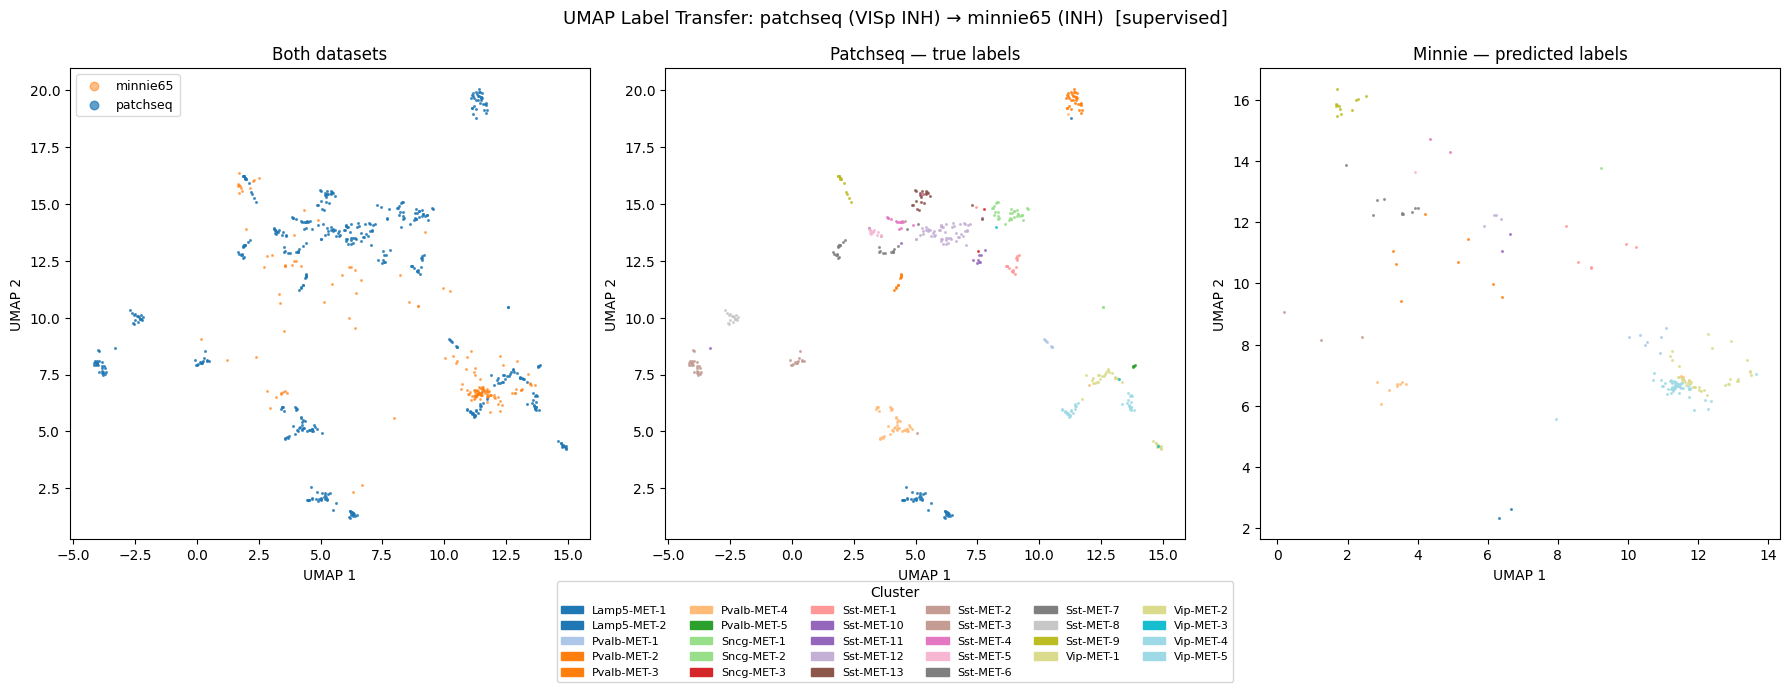

In [5]:
lt_inh_sup = UMAPLabelTransfer(DATA_ROOT, cell_type='inh')
lt_inh_sup.load_data()
lt_inh_sup.harmonize_features()
# lt_inh_sup.save_harmonized_h5ad('/scratch/h5ad_outputs')  # optional
lt_inh_sup.scale(method='standard')
lt_inh_sup.plot_alignment_diagnostics(top_n=5)
lt_inh_sup.fit_umap(mode='supervised')
lt_inh_sup.transfer_labels(k=3)
lt_inh_sup.plot_umap()

---
## Scaling options reference

Pass `method=` to `.scale()` to change the scaler:

| `method` | Scaler |
|----------|--------|
| `'standard'` | `StandardScaler` — zero mean, unit variance |
| `'robust'` | `RobustScaler` — median / IQR, robust to outliers |
| `'quantile'` | `QuantileTransformer(output_distribution='normal', n_quantiles=1000)` — maps to Gaussian, handles non-linear feature distributions |

## UMAP mode reference

| `mode` | Behaviour |
|--------|----------|
| `'unsupervised'` | Standard UMAP, geometry-only |
| `'supervised'` | Label-guided UMAP — patchseq cluster labels used as `y`; sharpens cluster separation |

## h5ad save

To persist the harmonised (pre-scaling) feature tables:

```python
lt.harmonize_features()
lt.save_harmonized_h5ad('/path/to/output_dir')
lt.scale()
```

Produces:
- `{output_dir}/exc_patchseq_harmonized.h5ad`
- `{output_dir}/exc_minnie_harmonized.h5ad`

(or `inh_` prefix for inhibitory)